# Data Visualisation Best Practices

This notebook teaches you how to turn basic, default charts into clear and compelling visualisations. Each task starts with a plain chart and progressively improves it — so you can see exactly what changes and why.

---

## Learning Objectives

By the end of this notebook, you will be able to:

1. Write **insight-driven titles** that tell the reader what to take away
2. **Use colour purposefully** — to highlight, encode meaning, or separate profit from loss
3. **Annotate key data points** so readers don't have to squint at axes
4. **Reduce clutter** (chart junk) to keep the focus on the data
5. **Choose the right chart type** for the question being asked
6. Apply consistent, colour-blind-friendly palettes

---

## The Five Core Principles (Reference Card)

Keep these in mind throughout the notebook:

| Principle | What it means in practice |
|-----------|---------------------------|
| **Lead with the insight** | Your title should state the finding, not just describe the data. *"Technology Leads Sales"* beats *"Sales by Category"*. |
| **Use colour with intent** | Colour should mean something: highlight the top/bottom, separate profit from loss, distinguish categories. Never use colour just for decoration. |
| **Annotate key points** | Add value labels, arrows, or callouts so readers can extract numbers without scanning axes. |
| **Reduce clutter** | Remove tick marks, borders, and grid lines that don't add information. `sns.despine()` is your friend. |
| **Respect your axes** | Start bar charts at zero. Use log scale if data spans orders of magnitude. Label units clearly. |

---

## Setup

We'll use the **Superstore dataset** — a fictional US retail company selling Furniture, Office Supplies, and Technology across four regions.

📥 Download the dataset here: https://www.kaggle.com/datasets/vivek468/superstore-dataset-final

Key columns we'll use:
- `Sales` — revenue from each order
- `Profit` — profit (can be negative if discounts or costs exceed revenue)
- `Category` / `Sub-Category` — product groupings
- `Region` / `State` — geographic breakdowns
- `Segment` — customer type: Consumer, Corporate, Home Office
- `Order Date` — when the order was placed
- `Discount` — discount rate applied (0 = no discount, 0.5 = 50% off)

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [3]:
df = pd.read_csv('Superstore.csv', encoding='latin-1')

# Parse dates once, up front
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Year'] = df['Order Date'].dt.year

print(f"Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head()

Dataset shape: 9,994 rows × 22 columns


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Year
0,1,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016
1,2,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016
2,3,CA-2016-138688,2016-06-12,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016
3,4,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015
4,5,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2015


In [4]:
# Quick data quality check — column types, nulls, and summary statistics
print("--- Column types ---")
print(df.dtypes)

print("\n--- Missing values ---")
print(df.isnull().sum()[df.isnull().sum() > 0])  # Only show columns with nulls

print("\n--- Numerical summary ---")
df[['Sales', 'Profit', 'Discount', 'Quantity']].describe().round(2)

--- Column types ---
Row ID                    int64
Order ID                 object
Order Date       datetime64[ns]
Ship Date                object
Ship Mode                object
Customer ID              object
Customer Name            object
Segment                  object
Country                  object
City                     object
State                    object
Postal Code               int64
Region                   object
Product ID               object
Category                 object
Sub-Category             object
Product Name             object
Sales                   float64
Quantity                  int64
Discount                float64
Profit                  float64
Year                      int32
dtype: object

--- Missing values ---
Series([], dtype: int64)

--- Numerical summary ---


,Sales,Profit,Discount,Quantity
count,9994.00,9994.00,9994.00,9994.00
mean,229.86,28.66,0.16,3.79
std,623.25,234.26,0.21,2.23
min,0.44,-6599.98,0.00,1.00
25%,17.28,1.73,0.00,2.00
50%,54.49,8.67,0.20,3.00
75%,209.94,29.36,0.20,5.00
max,22638.48,8399.98,0.80,14.00


---

## Task 1: Improve a Basic Bar Chart
**Business question:** Which product category brings in the most revenue?

Bar charts are the most common chart type — and the most commonly done poorly. This task shows the difference that a few targeted changes make.

Run the basic chart below first, then look at what's missing.

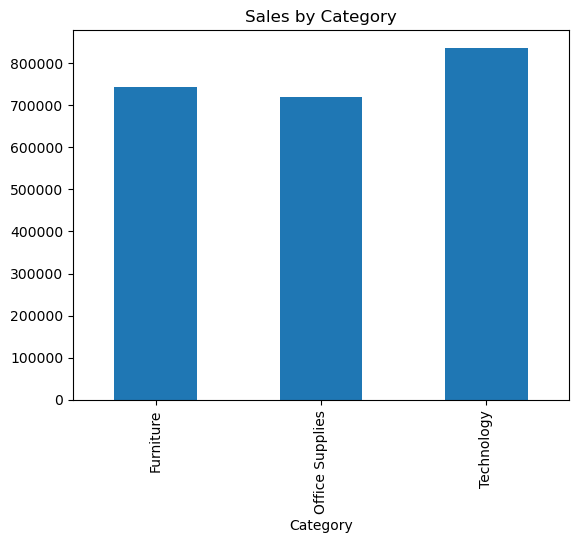

In [5]:
# Basic chart — default styling
sales_by_category = df.groupby('Category')['Sales'].sum()

sales_by_category.plot(kind='bar')
plt.title("Sales by Category")
plt.show()

**What's wrong with this chart?**
- The title *"Sales by Category"* describes the data but doesn't tell us anything — a reader still has to interpret it
- All bars are the same colour, so nothing draws the eye to what matters
- No value labels — readers have to estimate from the y-axis
- The chart frame (spines) adds visual noise without adding information
- The x-axis labels are rotated at an awkward angle

**Improvements to apply:**
- Write a title that states the finding
- Highlight the top category using the Okabe-Ito palette (colour-blind friendly)
- Add value labels above each bar
- Remove unnecessary chart borders with `sns.despine()`

> 💡 **Okabe-Ito palette** — a colour scheme designed to be distinguishable by people with the most common forms of colour blindness. Use `#E69F00` (amber) to highlight and `#009E73` (teal) as the base. See the Resources section for more.

**Reflection question:** What story does the improved chart tell that the basic one didn't?

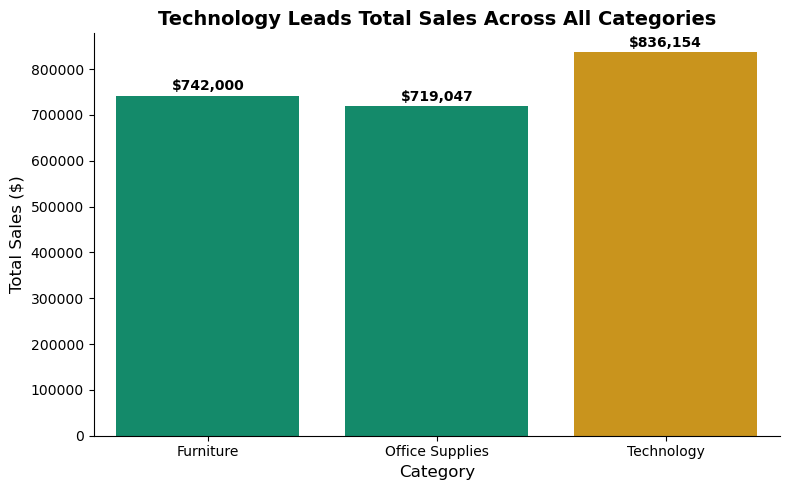

In [ ]:
# Improved chart
sales_by_category = df.groupby('Category')['Sales'].sum()

# Highlight the top category; use teal for the rest
colors = ['#E69F00' if val == sales_by_category.max() else '#009E73'
          for val in sales_by_category.values]

plt.figure(figsize=(8, 5))
sns.barplot(
    x=sales_by_category.index,
    y=sales_by_category.values,
    palette=colors,
    hue=sales_by_category.index,
    legend=False
)

# Insight-driven title
plt.title('Technology Leads Total Sales Across All Categories', fontsize=14, weight='bold')
plt.xlabel('Category', fontsize=12)
plt.ylabel('Total Sales ($)', fontsize=12)

# Value labels above each bar
for i, v in enumerate(sales_by_category.values):
    plt.text(i, v + 5000, f"${v:,.0f}", ha='center', va='bottom', fontsize=10, weight='bold') #i = where the bar is on the x-axis, v = height of the bar

sns.despine()  # Remove top and right spines for a cleaner look
plt.tight_layout()
plt.show()

---

## Task 2: Colour Encoding for Positive vs Negative Values
**Business question:** Which sub-categories are losing money?

When data has a meaningful midpoint (like zero profit), colour becomes a powerful tool — not just for aesthetics, but to encode meaning directly into the chart. A reader should be able to spot the loss-makers in under a second.


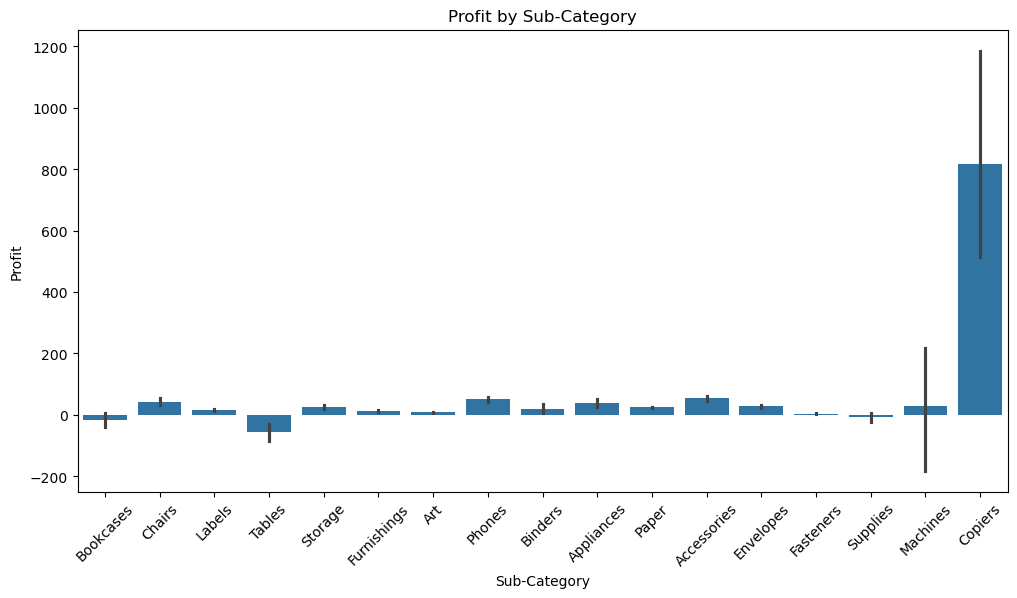

In [7]:
# Basic chart — no colour distinction between profit and loss
plt.figure(figsize=(12, 6))
sns.barplot(data=df, x='Sub-Category', y='Profit')
plt.xticks(rotation=45)
plt.title("Profit by Sub-Category")
plt.show()

**What's wrong with this chart?**
- Positive and negative bars look the same — you have to read the values to find the losses
- Categories are unsorted, making it hard to spot patterns
- There's no reference line at zero

**Improvements to apply:**
- Sort by profit value so loss-makers group naturally at one end
- Colour bars red for loss (`#D55E00`) and teal for profit (`#009E73`)
- Add a zero reference line (`plt.axhline(0)` or `plt.axvline(0)`)

**Reflection questions:**
1. Which sub-categories are consistently losing money?
2. What business action would you recommend based on this chart?

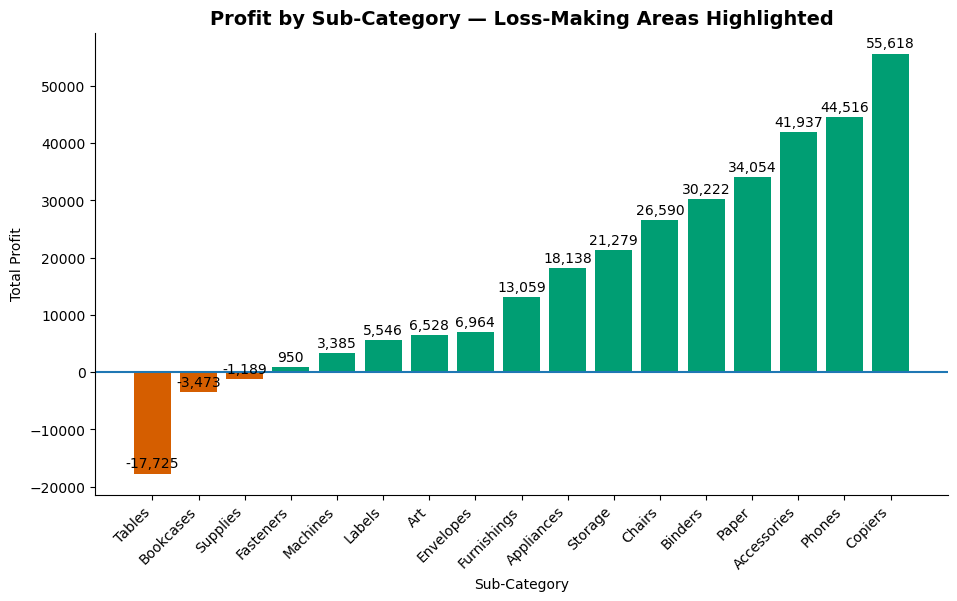

In [ ]:
plt.figure(figsize=(11,6))

# Improved chart — sorted, colour-coded, horizontal
profit_subcat = df.groupby('Sub-Category')['Profit'].sum().sort_values()

# Create custom color (orange for loss, green for profit)
colors = ['#D55E00' if x < 0 else '#009E73' for x in profit_subcat.values]

plt.bar(profit_subcat.index, profit_subcat.values, color=colors)

plt.title('Profit by Sub-Category — Loss-Making Areas Highlighted', fontsize=14, weight='bold')
plt.xlabel('Sub-Category')
plt.ylabel('Total Profit')

plt.xticks(rotation=45, ha='right')

# Add labels
for i, v in enumerate(profit_subcat.values):
    plt.text(i, v+500, f"{v:,.0f}", ha='center', va='bottom') #ha - horizontal alignment, centers the text over the bar, va - vertical alignment, the text appears just above the bar

# Add reference line at zero
plt.axhline(0)

sns.despine()
plt.show()

---

## Task 3: Time Series — Annotating Trends
**Business question:** How have total sales evolved over time? Are there seasonal patterns?

Line charts are the natural choice for time series data — they show continuity and make trends easy to follow. The key improvements here are **annotation** (marking the peak) and **visual cleanliness**.

> 📌 **When to use a line chart vs a bar chart for time data:** Use a line chart when the data is continuous and you want to emphasise the *trend*. Use bar charts when you want to compare *totals* for discrete periods.

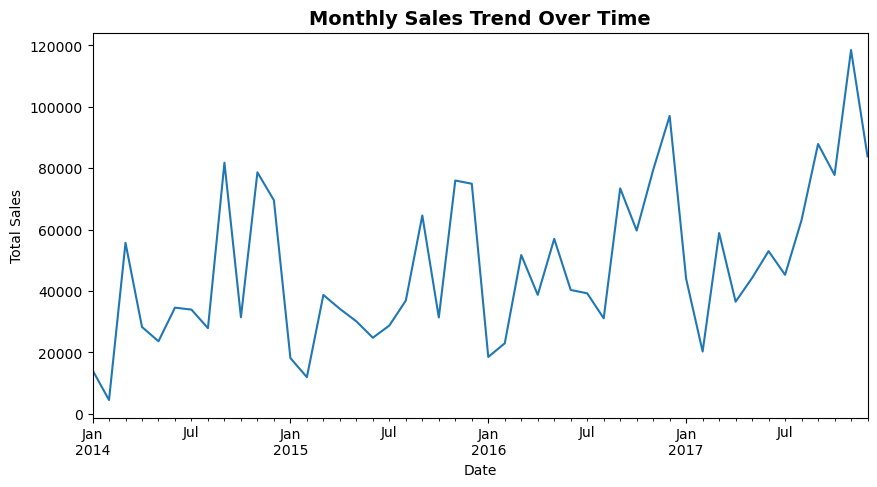

In [28]:
# Basic chart
monthly_sales = df.set_index('Order Date').resample('ME')['Sales'].sum()

plt.figure(figsize=(10, 5))
monthly_sales.plot()
plt.title('Monthly Sales Trend Over Time', fontsize=14, weight='bold')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.show()

**What could be better?**
- The default blue line is fine but blends into many other charts
- The peak month is hard to identify precisely — we have to mentally scan the line
- No `sns.despine()` — the chart border adds visual noise

**Improvements to apply:**
- Apply a consistent brand colour to the line
- Use `plt.scatter()` + `plt.text()` to mark and label the peak month
- Use `sns.set_style("whitegrid")` for a clean background grid

**Reflection question:** Do you notice any seasonal pattern? What might explain it?

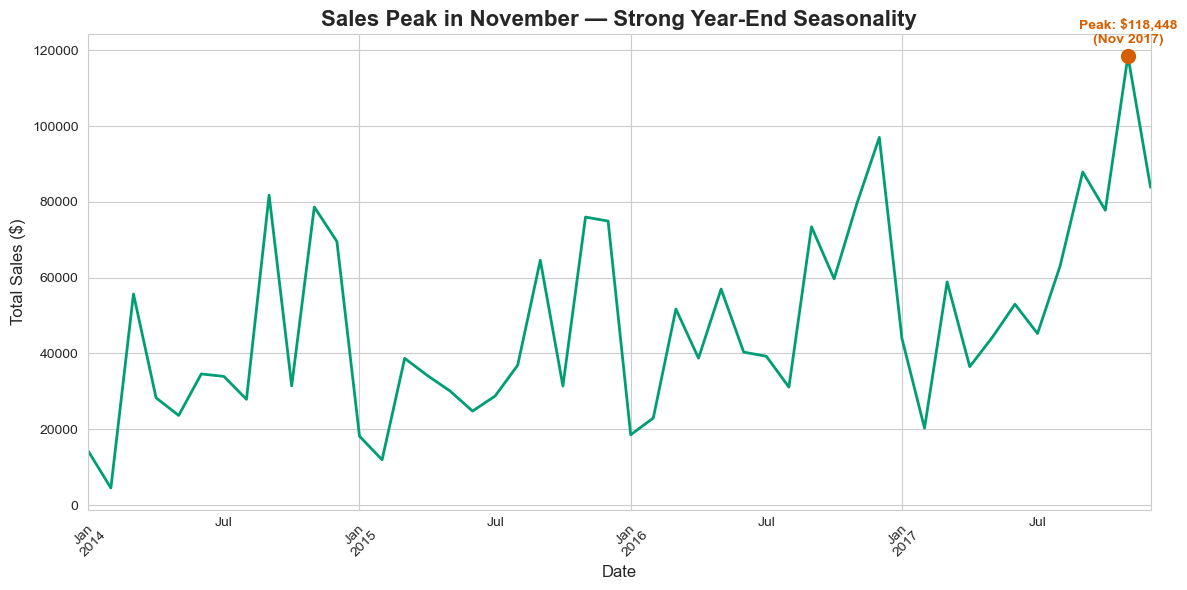

In [29]:
# Improved chart — peak annotated, cleaner look
monthly_sales = df.set_index('Order Date').resample('ME')['Sales'].sum()

plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

monthly_sales.plot(color="#009E73", linewidth=2)

plt.title('Sales Peak in November — Strong Year-End Seasonality',
          fontsize=16, weight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Total Sales ($)', fontsize=12)
plt.xticks(rotation=45)

# Highlight the peak month with a dot and label
max_month = monthly_sales.idxmax()
max_value = monthly_sales.max()
plt.scatter(max_month, max_value, color='#D55E00', s=100, zorder=5)
plt.text(max_month, max_value * 1.03,
         f'Peak: ${max_value:,.0f}\n({max_month.strftime("%b %Y")})',
         color='#D55E00', weight='bold', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

---

## Task 4: Small Multiples — Year-over-Year Growth by Category
**Business question:** Is each product category growing year on year?

When comparing trends across multiple groups, putting everything on one chart can create a tangled mess. **Small multiples** — a row of individual panels, one per group — let readers make comparisons without visual clutter.

This task also introduces **year-over-year (YoY) % change**, which is more meaningful than raw sales when groups differ in scale.

> 📌 **Small multiples rule of thumb:** If lines or bars would overlap significantly, or if you want readers to focus on the *shape* of each group's trend, use small multiples. If you mainly want to compare the *magnitude* between groups at a single point in time, a single chart is fine.

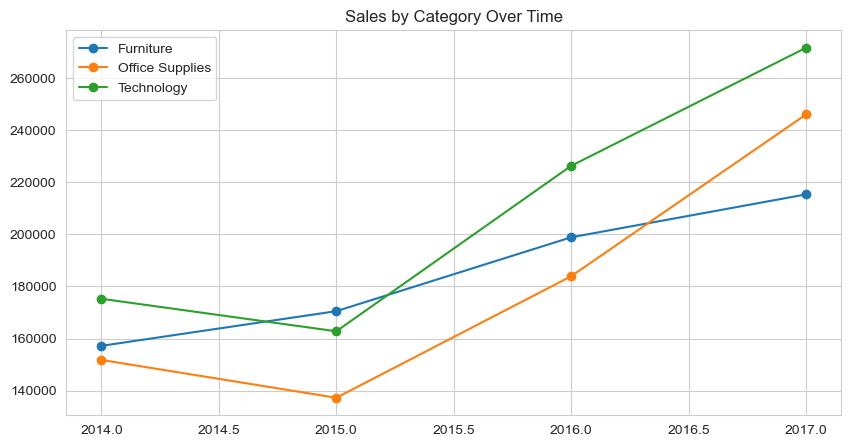

In [30]:
# Basic chart — all categories on one chart (hard to compare individually)
yearly = df.groupby(['Year', 'Category'])['Sales'].sum().reset_index()

plt.figure(figsize=(10, 5))
for cat in yearly['Category'].unique():
    subset = yearly[yearly['Category'] == cat]
    plt.plot(subset['Year'], subset['Sales'], marker='o', label=cat)

plt.title('Sales by Category Over Time')
plt.legend()
plt.show()

**What's wrong with this chart?**
- Raw sales values make Technology look dominant just because it has higher absolute values — it's hard to tell which category is *growing fastest*
- With more categories or years, the lines would overlap and become unreadable

**Improvements to apply:**
- Calculate **YoY % change** using `.pct_change()` so all categories are on the same scale
- Use `plt.subplots(1, n)` to create side-by-side panels — one per category
- Add a zero reference line so growth vs decline is immediately visible
- Use `sharey=True` so panels share a y-axis scale, making cross-category comparison fair

**Reflection questions:**
1. Which category had the strongest growth year? Which had a decline?
2. When are small multiples better than a single chart with multiple lines?

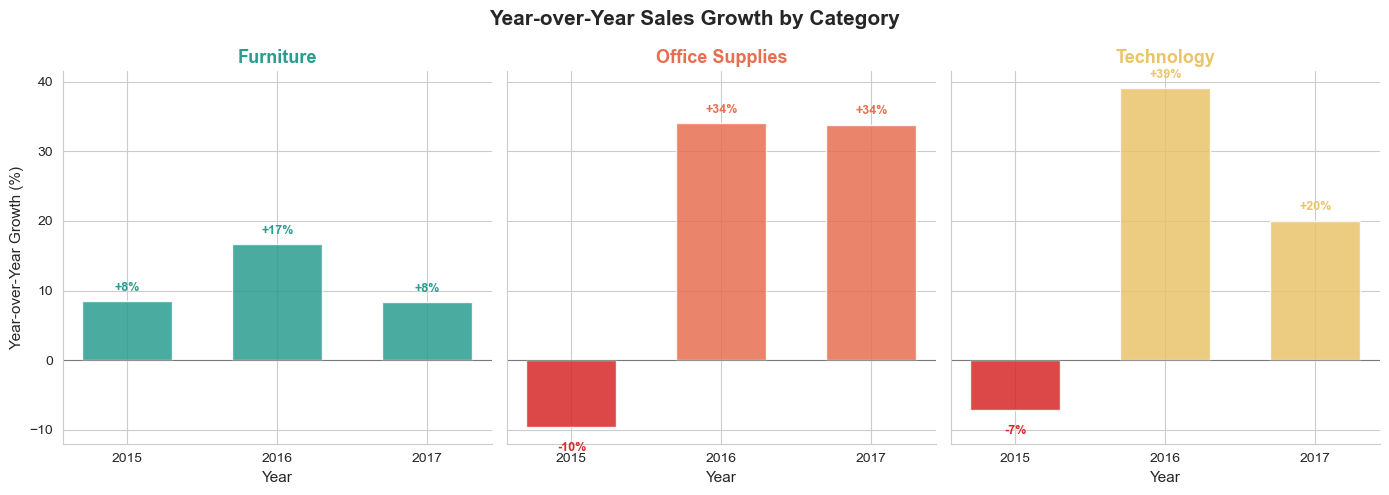

In [31]:
# Improved chart — YoY % growth as small multiples
yearly = df.groupby(['Year', 'Category'])['Sales'].sum().reset_index()
yearly['YoY Growth'] = yearly.groupby('Category')['Sales'].pct_change() * 100

categories = yearly['Category'].unique()
palette = ['#2a9d8f', '#e76f51', '#e9c46a']

fig, axes = plt.subplots(1, len(categories), figsize=(14, 5), sharey=True)

for ax, cat, color in zip(axes, categories, palette):
    subset = yearly[yearly['Category'] == cat].dropna(subset=['YoY Growth'])

    # Red for negative growth, category colour for positive
    bar_colors = [color if v >= 0 else '#d62828' for v in subset['YoY Growth']]
    ax.bar(subset['Year'], subset['YoY Growth'], color=bar_colors, width=0.6, alpha=0.85)

    ax.axhline(0, color='black', linewidth=0.8, linestyle='-', alpha=0.4)

    # Annotate each bar with its percentage
    for year, val in zip(subset['Year'], subset['YoY Growth']):
        ax.text(year, val + (1.5 if val >= 0 else -3.5),
                f'{val:+.0f}%', ha='center', fontsize=9, weight='bold',
                color=color if val >= 0 else '#d62828')

    ax.set_title(cat, fontsize=13, weight='bold', color=color)
    ax.set_xlabel('Year', fontsize=11)
    ax.set_xticks(subset['Year'])
    sns.despine(ax=ax)

axes[0].set_ylabel('Year-over-Year Growth (%)', fontsize=11)
fig.suptitle('Year-over-Year Sales Growth by Category', fontsize=15, weight='bold')
plt.tight_layout()
plt.show()

---

## Task 5: Scatter Plots — Revealing Relationships
**Business question:** Does offering higher discounts actually hurt profit?

Scatter plots are the best tool for exploring the **relationship between two continuous variables**. This task shows how to go beyond a basic scatter — using colour encoding, a trend line, and a reference zone to make the business implication unmistakable.

> 📌 **A note on overplotting:** When thousands of data points overlap, a scatter plot becomes a dark blob. The fix is to reduce `alpha` (transparency) and point size (`s`), so dense areas appear darker and sparse areas lighter — this is called a **density impression**.

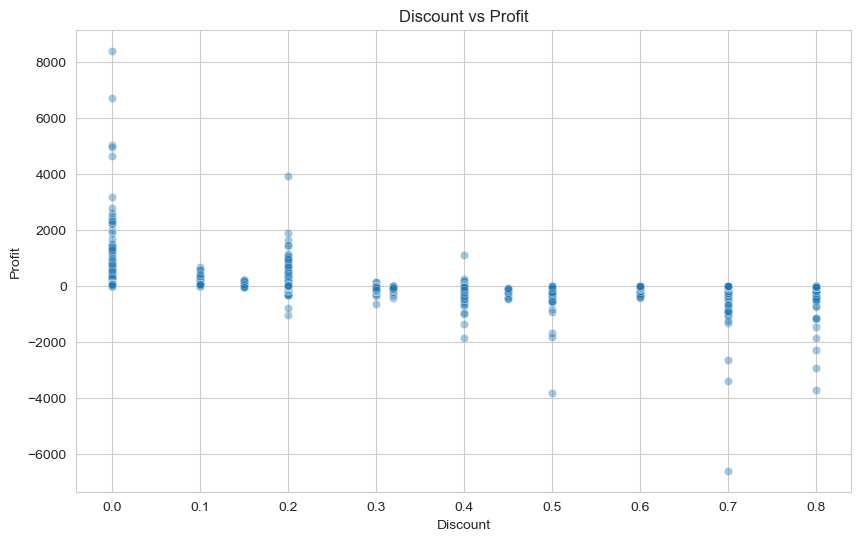

In [32]:
# Basic scatter — no colour, no trend, hard to draw conclusions
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Discount', y='Profit', alpha=0.4)
plt.title("Discount vs Profit")
plt.xlabel('Discount')
plt.ylabel('Profit')
plt.show()

**What's wrong with this chart?**
- All points are the same colour — profitable and loss-making orders look identical
- There's no trend line, so the direction of the relationship isn't clear
- The x-axis shows decimals (0.2 = 20% discount) — formatting as percentages would be clearer
- The title describes the axes but draws no conclusion

**Improvements to apply:**
- Colour-encode each point: teal for profit, red/orange for loss
- Add a linear trend line using `scipy.stats.linregress` to show the overall direction
- Shade the "break-even zone" using `plt.axvspan()`
- Format x-axis as percentages

**Reflection question:** At roughly what discount level does profit reliably turn negative? What business action would you recommend?

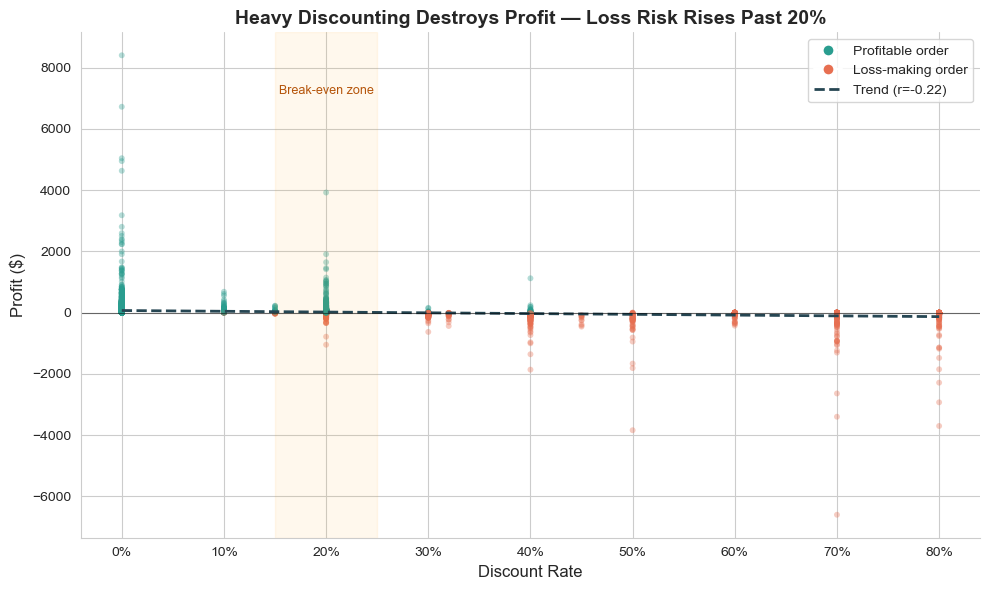

In [33]:
# Improved scatter — colour-coded, trend line, annotated break-even zone
from scipy import stats
from matplotlib.lines import Line2D

plt.figure(figsize=(10, 6))

# Colour-encode profit vs loss
colors = ['#2a9d8f' if p >= 0 else '#e76f51' for p in df['Profit']]

plt.scatter(
    df['Discount'],
    df['Profit'],
    c=colors,
    alpha=0.35,
    s=18,
    linewidths=0
)

# Trend line
slope, intercept, r, p, _ = stats.linregress(df['Discount'], df['Profit'])
x_line = np.linspace(df['Discount'].min(), df['Discount'].max(), 100)
plt.plot(x_line, slope * x_line + intercept,
         color='#264653', linewidth=2, linestyle='--', label=f'Trend (r={r:.2f})')

# Zero profit reference line
plt.axhline(0, color='black', linewidth=0.8, linestyle='-', alpha=0.5)

# Shade the approximate break-even zone
plt.axvspan(0.15, 0.25, alpha=0.07, color='orange')
plt.text(0.20, df['Profit'].max() * 0.85, 'Break-even zone',
         ha='center', fontsize=9, color='#b5550b')

# Custom legend
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#2a9d8f',
           markersize=8, label='Profitable order'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#e76f51',
           markersize=8, label='Loss-making order'),
    Line2D([0], [0], color='#264653', linewidth=2, linestyle='--',
           label=f'Trend (r={r:.2f})')
]
plt.legend(handles=legend_elements, fontsize=10)

plt.title('Heavy Discounting Destroys Profit — Loss Risk Rises Past 20%',
          fontsize=14, weight='bold')
plt.xlabel('Discount Rate', fontsize=12)
plt.ylabel('Profit ($)', fontsize=12)

# Format x-axis as percentages
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x*100)}%'))

sns.despine()
plt.tight_layout()
plt.show()

---

## Task 6: Part-to-Whole — Sales Share by Segment Over Time
**Business question:** Has the mix of customer segments shifted over the years?

When you want to show *composition* — how a whole is divided into parts — stacked charts are the right tool. But there's an important distinction: **raw stacked bars** show totals, while **100% stacked bars** show proportions. The right choice depends on whether total volume or relative share matters more.

> 📌 **Stacked bar vs stacked area:** Use stacked *bars* for discrete time periods (years). Use stacked *area* charts for continuous time series (months) where you want to emphasise flow and momentum over time.

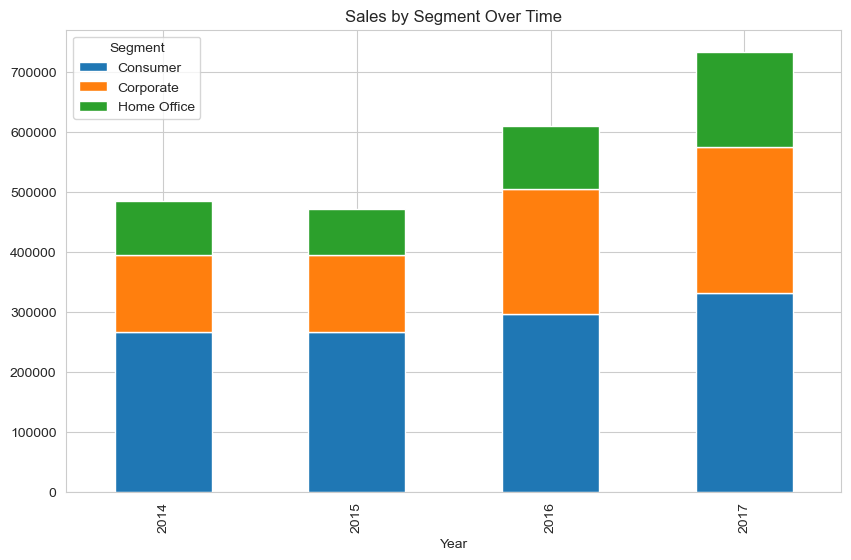

In [34]:
# Basic chart — raw stacked bars (hard to compare proportions across years)
seg_year = df.groupby(['Year', 'Segment'])['Sales'].sum().unstack()

seg_year.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title('Sales by Segment Over Time')
plt.show()

**What's wrong with this chart?**
- Because total sales grew over time, the bars get taller each year — but it's impossible to tell whether the *mix* changed
- The default colour palette isn't colour-blind friendly
- No percentage labels inside segments

**Improvements to apply:**
- Normalise to 100% so each bar represents the full year and segments show their share
- Add percentage labels inside each segment (skip if the segment is too small)
- Use a consistent, intentional palette per segment

**Reflection questions:**
1. Has the sales mix shifted between segments over the years?
2. When would a 100% stacked bar *mislead* you? (Hint: think about what it hides.)

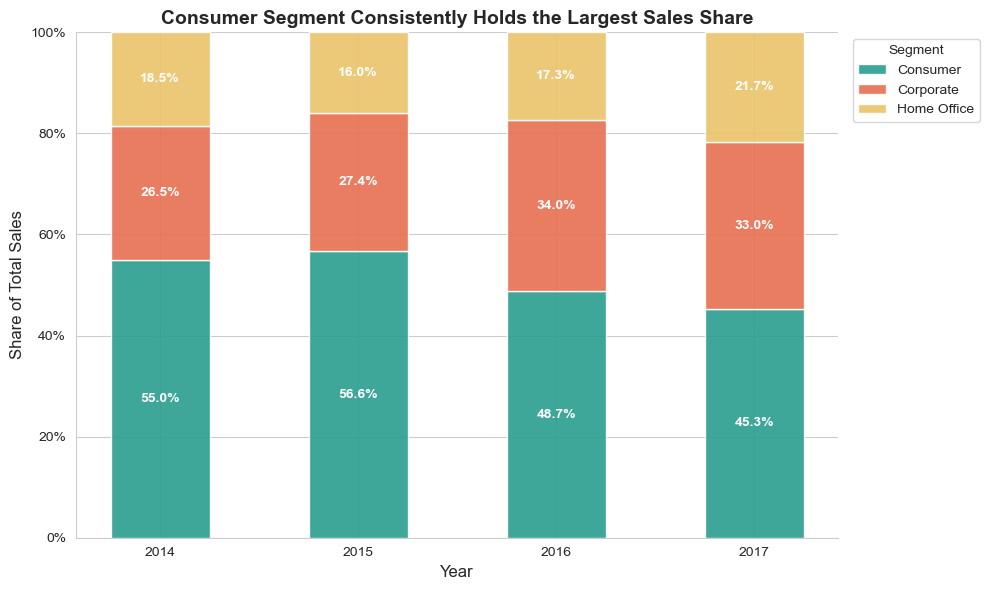

In [35]:
# Improved chart — 100% stacked bars showing proportion
seg_year = df.groupby(['Year', 'Segment'])['Sales'].sum().unstack()
seg_pct = seg_year.div(seg_year.sum(axis=1), axis=0) * 100  # Normalise to 100%

palette = {'Consumer': '#2a9d8f', 'Corporate': '#e76f51', 'Home Office': '#e9c46a'}
years = seg_pct.index.astype(str)
segments = seg_pct.columns.tolist()

fig, ax = plt.subplots(figsize=(10, 6))
bottoms = [0] * len(years)

for seg in segments:
    values = seg_pct[seg].values
    ax.bar(years, values, bottom=bottoms,
           label=seg, color=palette[seg], width=0.5, alpha=0.9)

    # Add percentage labels inside each segment (skip if too narrow)
    for i, (val, bot) in enumerate(zip(values, bottoms)):
        if val > 5:
            ax.text(i, bot + val / 2, f'{val:.1f}%',
                    ha='center', va='center', fontsize=10,
                    color='white', weight='bold')
    bottoms = [b + v for b, v in zip(bottoms, values)]

ax.set_ylim(0, 100)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}%'))
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Share of Total Sales', fontsize=12)
ax.legend(title='Segment', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=10)

plt.title('Consumer Segment Consistently Holds the Largest Sales Share',
          fontsize=14, weight='bold')
sns.despine()
plt.tight_layout()
plt.show()

---

## Task 7: Heatmaps — Two-Dimensional Comparison
**Business question:** Which combinations of category and region are most and least profitable?

When you need to compare values across **two categorical dimensions simultaneously**, a heatmap is often the clearest solution. It's essentially a table where colour replaces numbers — allowing patterns to emerge at a glance.

> 📌 **Heatmap vs bar chart:** Use a heatmap when you have a grid of values (rows × columns) and want to highlight the *pattern across the whole grid*. Use a bar chart when you want to precisely compare *individual values* or rank them. Heatmaps are great for showing "where are the hotspots?" — bar charts are better for "how much bigger is A than B?"

> 📌 **Diverging colour palettes:** When your data has a meaningful midpoint (like zero profit), use a diverging palette — one colour for above, another for below, white/pale in the middle. `RdYlGn` (red–yellow–green) is intuitive for profit/loss contexts. Set `center=0` in `sns.heatmap()` to anchor the palette correctly.

In [36]:
# Basic version — plain table (no visual encoding)
pivot = df.pivot_table(values='Profit', index='Category', columns='Region', aggfunc='sum')
print(pivot.round(0))

Region           Central     East    South     West
Category                                           
Furniture        -2871.0   3046.0   6771.0  11505.0
Office Supplies   8880.0  41015.0  19986.0  52610.0
Technology       33697.0  47462.0  19992.0  44304.0


**What's wrong with this approach?**
- The plain table requires you to read every number to spot patterns
- Loss-making cells aren't immediately obvious — there's no visual signal
- With more rows or columns, tables become very hard to scan

**Improvements to apply:**
- Convert to a heatmap with `sns.heatmap()`
- Use `cmap='RdYlGn'` with `center=0` so profit is green and loss is red
- Add `annot=True` so exact values are still readable
- Format annotations as `$K` for compactness

**Reflection questions:**
1. Which Category × Region combination is the biggest problem area?
2. Does Furniture lose money in *every* region, or just some?

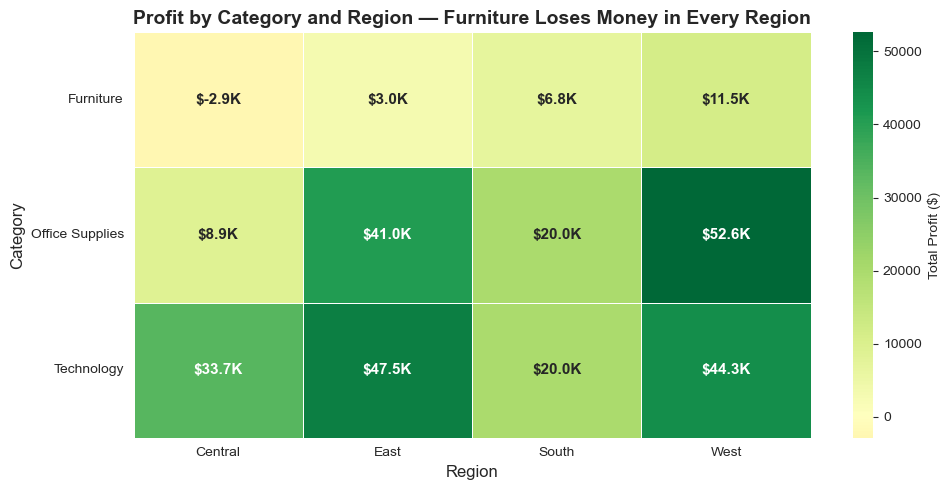

In [37]:
# Improved version — annotated heatmap with diverging colour palette
pivot = df.pivot_table(values='Profit', index='Category', columns='Region', aggfunc='sum')

# Format cell annotations as $K for readability
annot_labels = pivot.map(lambda v: f'${v/1000:.1f}K')

plt.figure(figsize=(10, 5))

sns.heatmap(
    pivot,
    annot=annot_labels,
    fmt='',
    cmap='RdYlGn',           # Red = loss, green = profit
    center=0,                # Anchor colour scale at zero
    linewidths=0.5,
    linecolor='white',
    annot_kws={'size': 11, 'weight': 'bold'},
    cbar_kws={'label': 'Total Profit ($)'}
)

plt.title('Profit by Category and Region — Furniture Loses Money in Every Region',
          fontsize=14, weight='bold')
plt.xlabel('Region', fontsize=12)
plt.ylabel('Category', fontsize=12)
plt.xticks(rotation=0)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

---

## Summary: Chart Type Decision Guide

Use this table when deciding which chart type to reach for:

| Question type | Best chart type | Example from this notebook |
|---------------|----------------|----------------------------|
| Compare totals across categories | Bar chart (vertical or horizontal) | Task 1 — Sales by Category |
| Rank with positive + negative values | Horizontal bar chart | Task 2 — Profit by Sub-Category |
| Show trend over time | Line chart | Task 3 — Monthly Sales |
| Compare trends across groups | Small multiples | Task 4 — YoY Growth by Category |
| Relationship between two variables | Scatter plot | Task 5 — Discount vs Profit |
| Show composition / part-to-whole | Stacked bar (100%) | Task 6 — Segment Sales Share |
| Compare values across two dimensions | Heatmap | Task 7 — Profit by Category × Region |

---

## Resources

- **Seaborn documentation:** https://seaborn.pydata.org/
- **Matplotlib documentation:** https://matplotlib.org/stable/
- **Okabe-Ito colour-blind-friendly palette:** https://siegal.bio.nyu.edu/color-palette/
- **Fundamentals of Data Visualisation (free online book):** https://clauswilke.com/dataviz/
- **The Data Visualisation Catalogue (chart type reference):** https://datavizcatalogue.com/

---

## Colour Reference

The colours used throughout this notebook follow the **Okabe-Ito** palette:

| Hex | Use case |
|-----|----------|
| `#009E73` | Base / neutral positive (teal) |
| `#E69F00` | Highlight / top value (amber) |
| `#D55E00` | Loss / warning / lowest value (burnt orange) |
| `#0072B2` | Secondary accent (blue) |
| `#2a9d8f` | Category 1 (teal-green) |
| `#e76f51` | Category 2 (coral) |
| `#e9c46a` | Category 3 (yellow) |